In [11]:
# %% 单元格1: 导入库与设置
import os
import numpy as np
import math
import random
import datetime
import time
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange, Reduce
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# 设置随机种子以确保结果可复现
seed = 2021
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 设置GPU
gpus = [0]
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, gpus))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
# %% 单元格2: 模型定义 (与之前保持一致，确保是您原始的五折代码模型结构)
class PatchEmbedding(nn.Module):
    def __init__(self, emb_size=40):
        super().__init__()
        self.shallownet = nn.Sequential(
            nn.Conv2d(1, 40, (1, 25), (1, 1)),
            nn.Conv2d(40, 40, (62, 1), (1, 1)),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.AvgPool2d((1, 75), (1, 15)),
            nn.Dropout(0.5),
        )
        self.projection = nn.Sequential(
            nn.Conv2d(40, emb_size, (1, 1), stride=(1, 1)),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.shallownet(x)
        x = self.projection(x)
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, num_heads, dropout):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.keys = nn.Linear(emb_size, emb_size)
        self.queries = nn.Linear(emb_size, emb_size)
        self.values = nn.Linear(emb_size, emb_size)
        self.att_drop = nn.Dropout(dropout)
        self.projection = nn.Linear(emb_size, emb_size)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        queries = rearrange(self.queries(x), "b n (h d) -> b h n d", h=self.num_heads)
        keys = rearrange(self.keys(x), "b n (h d) -> b h n d", h=self.num_heads)
        values = rearrange(self.values(x), "b n (h d) -> b h n d", h=self.num_heads)
        energy = torch.einsum('bhqd, bhkd -> bhqk', queries, keys)
        if mask is not None:
            fill_value = torch.finfo(torch.float32).min
            energy = energy.masked_fill(~mask, fill_value)
        scaling = self.emb_size ** (1 / 2)
        att = F.softmax(energy / scaling, dim=-1)
        att = self.att_drop(att)
        out = torch.einsum('bhal, bhlv -> bhav ', att, values)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.projection(out)
        return out

class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x

class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size, expansion, drop_p):
        super().__init__(
            nn.Linear(emb_size, expansion * emb_size),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),
        )

class TransformerEncoderBlock(nn.Sequential):
    def __init__(self, emb_size, num_heads=5, drop_p=0.5, forward_expansion=4, forward_drop_p=0.5):
        super().__init__(
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                MultiHeadAttention(emb_size, num_heads, drop_p),
                nn.Dropout(drop_p)
            )),
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                FeedForwardBlock(emb_size, expansion=forward_expansion, drop_p=forward_drop_p),
                nn.Dropout(drop_p)
            ))
        )

class TransformerEncoder(nn.Sequential):
    def __init__(self, depth, emb_size):
        super().__init__(*[TransformerEncoderBlock(emb_size) for _ in range(depth)])

class ClassificationHead(nn.Module):
    def __init__(self, input_dim, n_classes=3):
        super().__init__()
        # 使用动态计算的特征维度
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.contiguous().view(x.size(0), -1)  # 展平
        out = self.fc(x)
        return x, out

class ViT(nn.Module):
    def __init__(self, emb_size=40, depth=6, n_classes=3, **kwargs):
        super().__init__()
        self.patch_embedding = PatchEmbedding(emb_size)
        self.transformer = TransformerEncoder(depth, emb_size)
        # 特征维度将在首次前向传播后动态确定
        self.feature_dim = None
        self.classification_head = None
        self.n_classes = n_classes

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.transformer(x)
        
        # 动态创建分类头（如果尚未创建）
        if self.classification_head is None:
            self.feature_dim = x.shape[1] * x.shape[2]  # num_patches * emb_size
            self.classification_head = ClassificationHead(self.feature_dim, self.n_classes).to(x.device)
            print(f"动态创建分类头，特征维度: {self.feature_dim}")
        
        features, outputs = self.classification_head(x)
        return features, outputs

In [13]:
# %% 单元格3: 数据加载与预处理函数 (适配.h5文件和五折交叉验证)
def load_subject_data(h5_file_path):
    """
    加载单个被试的.h5文件。
    假设.h5文件中数据存储在'x'键下，标签存储在'y'键下。
    您可能需要根据您文件的实际结构调整这些键名。
    """
    with h5py.File(h5_file_path, 'r') as f:
        # 尝试常见的数据和标签键名
        data_keys = ['x', 'data', 'X', 'EEG', 'eeg', 'features']
        label_keys = ['y', 'label', 'Y', 'labels', 'target']
        
        data = None
        labels = None
        
        # 查找数据
        for key in data_keys:
            if key in f:
                data = f[key][:]
                print(f"  找到数据，键名: '{key}'，形状: {data.shape}")
                break
        
        # 查找标签
        for key in label_keys:
            if key in f:
                labels = f[key][:]
                print(f"  找到标签，键名: '{key}'，形状: {labels.shape}")
                break
        
        if data is None:
            raise ValueError(f"在文件 {h5_file_path} 中找不到数据。")
        if labels is None:
            raise ValueError(f"在文件 {h5_file_path} 中找不到标签。")
        
        # 确保标签是1D数组
        if labels.ndim > 1:
            labels = labels.squeeze()
        
        # 标签转换 (如果原始标签是1,2,3，转换为0,1,2)
        unique_labels = np.unique(labels)
        print(f"  原始标签值: {unique_labels}")
        if set(unique_labels) == {1, 2, 3}:
            labels = labels - 1
            print("  已将标签从[1,2,3]转换为[0,1,2]")
        elif set(unique_labels) == {0, 1, 2}:
            print("  标签已经是[0,1,2]格式")
        else:
            print(f"  警告: 标签值域为 {unique_labels}，预期为 {{0,1,2}} 或 {{1,2,3}}")
        
        return data, labels

def prepare_fold_data(train_idx, test_idx, all_data, all_labels, target_mean=None, target_std=None):
    """
    为单折准备训练和测试数据，并进行标准化。
    """
    train_data = all_data[train_idx]
    train_label = all_labels[train_idx]
    test_data = all_data[test_idx]
    test_label = all_labels[test_idx]
    
    # 标准化：使用训练集的均值和标准差
    if target_mean is None or target_std is None:
        target_mean = np.mean(train_data, axis=(0, 2), keepdims=True)
        target_std = np.std(train_data, axis=(0, 2), keepdims=True)
    
    train_data = (train_data - target_mean) / (target_std + 1e-8)
    test_data = (test_data - target_mean) / (target_std + 1e-8)
    
    return train_data, train_label, test_data, test_label

def get_dataloader(data, label, batch_size=64, shuffle=True):
    """
    创建PyTorch DataLoader。
    """
    data_tensor = torch.from_numpy(data).float()
    label_tensor = torch.from_numpy(label).long()
    
    # 调整数据形状: [样本数, 1, 通道数, 时间点]
    if data_tensor.ndim == 3:
        data_tensor = data_tensor.unsqueeze(1)
    
    dataset = TensorDataset(data_tensor, label_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader

In [14]:
# %% 单元格4: 训练与评估函数
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        _, output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.size(0)
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            _, output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item() * data.size(0)
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    
    avg_loss = total_loss / total
    accuracy = 100. * correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

In [15]:
# %% 单元格5: 主程序
def main():
    # --- 配置参数 ---
    # 请修改为您的实际文件路径
    data_dir = "/mnt/dataset0/Jity/EEG-Conformer-main/EEG-Conformer-main/data/SEED"  # 请修改为您的.h5文件所在目录
    train_file = os.path.join(data_dir, "train.h5")
    val_file = os.path.join(data_dir, "val.h5")
    test_file = os.path.join(data_dir, "test_x_only.h5")
    
    output_pred_file = "test_predictions.txt"  # 预测结果输出文件
    best_model_path = "best_model_seed.pth"    # 最佳模型保存路径
    
    batch_size = 64
    num_epochs = 100
    learning_rate = 0.0002
    patience = 10  # 早停耐心值
    
    # --- 1. 加载数据 ---
    print("=== 加载数据 ===")
    train_data, train_labels = load_h5_data(train_file, has_label=True)
    val_data, val_labels = load_h5_data(val_file, has_label=True)
    test_data = load_h5_data(test_file, has_label=False)  # 无标签
    
    print(f"\n数据统计:")
    print(f"  训练集: {train_data.shape}, 标签: {train_labels.shape}")
    print(f"  验证集: {val_data.shape}, 标签: {val_labels.shape}")
    print(f"  测试集: {test_data.shape}")
    
    # 检查数据形状并调整
    if train_data.ndim == 3:
        print("\n检测到3维数据，添加通道维度...")
        train_data = np.expand_dims(train_data, axis=1)
        val_data = np.expand_dims(val_data, axis=1)
        test_data = np.expand_dims(test_data, axis=1)
        print(f"  调整后训练集形状: {train_data.shape}")
    elif train_data.ndim == 4:
        print(f"\n检测到4维数据，形状: {train_data.shape}")
    
    # --- 2. 数据预处理（标准化）---
    print("\n=== 数据预处理（标准化）===")
    train_data_norm, val_data_norm, test_data_norm, mean, std = preprocess_data(
        train_data, val_data, test_data
    )
    
    # --- 3. 计算输入形状 ---
    # 模型输入形状: [channels, height, width] = [1, 62, 时间点]
    input_shape = (1, train_data_norm.shape[2], train_data_norm.shape[3])
    print(f"\n模型输入形状: {input_shape}")
    
    # --- 4. 创建数据加载器 ---
    print("\n=== 创建数据加载器 ===")
    train_loader = prepare_dataloader(train_data_norm, train_labels, batch_size=batch_size, shuffle=True)
    val_loader = prepare_dataloader(val_data_norm, val_labels, batch_size=batch_size, shuffle=False)
    
    # 测试集没有标签
    test_tensor = torch.from_numpy(test_data_norm).float()
    if test_tensor.ndim == 3:
        test_tensor = test_tensor.unsqueeze(1)
    test_dataset = TensorDataset(test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # --- 5. 初始化模型 ---
    print("\n=== 初始化模型 ===")
    model = ViT(input_shape=input_shape, emb_size=40, depth=6, n_classes=3).to(device)
    
    if len(gpus) > 1 and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model, device_ids=list(range(len(gpus))))
    
    # 打印模型结构
    print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
    
    # 测试模型前向传播
    with torch.no_grad():
        test_batch = next(iter(train_loader))[0][:2].to(device)  # 取2个样本
        features, outputs = model(test_batch)
        print(f"测试前向传播 - 输入: {test_batch.shape}, 输出: {outputs.shape}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    
    # --- 6. 训练循环（带早停）---
    print(f"\n=== 开始训练，共 {num_epochs} 轮 ===")
    best_val_acc = 0.0
    patience_counter = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # 记录损失和准确率
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1:03d}/{num_epochs:03d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✓ 保存最佳模型，验证准确率: {val_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n早停于第 {epoch+1} 轮")
                break
    
    print(f"\n训练完成，最佳验证准确率: {best_val_acc:.2f}%")
    
    # --- 7. 在测试集上进行预测 ---
    print("\n=== 加载最佳模型进行测试集预测 ===")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    
    all_predictions = []
    
    with torch.no_grad():
        for batch in test_loader:
            data = batch[0].to(device)  # batch[0] 因为只有数据，没有标签
            _, outputs = model(data)
            _, predicted = outputs.max(1)
            all_predictions.extend(predicted.cpu().numpy())
    
    # 确保预测值是0,1,2
    all_predictions = np.array(all_predictions, dtype=int)
    
    # --- 8. 保存预测结果 ---
    print(f"\n=== 保存预测结果到 {output_pred_file} ===")
    np.savetxt(output_pred_file, all_predictions, fmt='%d')
    
    # 打印预测分布
    unique, counts = np.unique(all_predictions, return_counts=True)
    print("预测类别分布:")
    for cls, count in zip(unique, counts):
        print(f"  类别 {cls}: {count} 个样本 ({count/len(all_predictions)*100:.1f}%)")
    
    return all_predictions, train_losses, val_losses, train_accs, val_accs

# 运行主程序
if __name__ == "__main__":
    start_time = time.time()
    predictions, train_losses, val_losses, train_accs, val_accs = main()
    end_time = time.time()
    print(f"\n总耗时: {end_time - start_time:.2f} 秒")

=== 加载数据 ===
  找到数据，键名: 'X'，形状: (900, 62, 400)
  找到标签，键名: 'y'，形状: (900,)
  原始标签值: [0 1 2]
  标签已经是[0,1,2]格式
  找到数据，键名: 'X'，形状: (450, 62, 400)
  找到标签，键名: 'y'，形状: (450,)
  原始标签值: [0 1 2]
  标签已经是[0,1,2]格式
  找到数据，键名: 'X'，形状: (450, 62, 400)

数据统计:
  训练集: (900, 62, 400), 标签: (900,)
  验证集: (450, 62, 400), 标签: (450,)
  测试集: (450, 62, 400)

检测到3维数据，添加通道维度...
  调整后训练集形状: (900, 1, 62, 400)

=== 数据预处理（标准化）===
  标准化 - 均值: (1, 1, 62, 1), 标准差: (1, 1, 62, 1)

模型输入形状: (1, 62, 400)

=== 创建数据加载器 ===
  数据形状调整: (900, 1, 62, 400) -> torch.Size([900, 1, 62, 400])
  数据形状调整: (450, 1, 62, 400) -> torch.Size([450, 1, 62, 400])

=== 初始化模型 ===
模型参数量: 220,320
动态创建分类头，特征维度: 840
测试前向传播 - 输入: torch.Size([2, 1, 62, 400]), 输出: torch.Size([2, 3])

=== 开始训练，共 100 轮 ===
Epoch 001/100 | Train Loss: 1.1210 | Train Acc: 34.89% | Val Loss: 1.1104 | Val Acc: 33.33%
  ✓ 保存最佳模型，验证准确率: 33.33%
Epoch 002/100 | Train Loss: 1.1226 | Train Acc: 33.89% | Val Loss: 1.1023 | Val Acc: 34.89%
  ✓ 保存最佳模型，验证准确率: 34.89%
Epoch 003/100 | Train Lo

/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2437880/2725840583.py:23: UserWarning: Glyph 21644 (\N{CJK UN

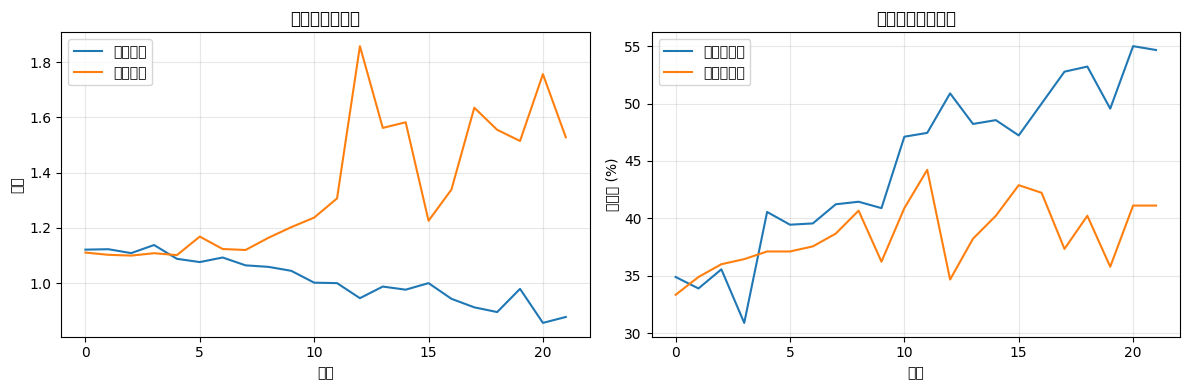

In [16]:
# %% 单元格6: 可视化训练过程
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 损失曲线
    ax1.plot(train_losses, label='训练损失')
    ax1.plot(val_losses, label='验证损失')
    ax1.set_xlabel('轮次')
    ax1.set_ylabel('损失')
    ax1.set_title('训练和验证损失')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 准确率曲线
    ax2.plot(train_accs, label='训练准确率')
    ax2.plot(val_accs, label='验证准确率')
    ax2.set_xlabel('轮次')
    ax2.set_ylabel('准确率 (%)')
    ax2.set_title('训练和验证准确率')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 绘制训练曲线
if 'train_losses' in locals() and len(train_losses) > 0:
    plot_training_curves(train_losses, val_losses, train_accs, val_accs)
else:
    print("训练数据不可用，请先运行主程序。")

In [17]:
# %% 单元格7: 检查预测结果
def check_predictions(file_path="test_predictions.txt"):
    if os.path.exists(file_path):
        preds = np.loadtxt(file_path, dtype=int)
        print(f"从 '{file_path}' 加载了 {len(preds)} 个预测")
        print(f"前20个预测: {preds[:20]}")
        
        unique, counts = np.unique(preds, return_counts=True)
        print("\n类别分布:")
        for cls, count in zip(unique, counts):
            print(f"  类别 {cls}: {count} 个样本 ({count/len(preds)*100:.1f}%)")
        
        # 检查是否只有0,1,2三个类别
        if set(unique) <= {0, 1, 2}:
            print("✓ 预测结果只包含0,1,2三个类别")
        else:
            print(f"⚠ 警告: 预测结果包含非预期类别: {unique}")
    else:
        print(f"文件 '{file_path}' 不存在")

check_predictions()

从 'test_predictions.txt' 加载了 450 个预测
前20个预测: [0 2 2 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 0 2]

类别分布:
  类别 0: 292 个样本 (64.9%)
  类别 2: 158 个样本 (35.1%)
✓ 预测结果只包含0,1,2三个类别
